In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Electromagnetismo II
## Proyecto 1. Ecuación de Laplace en dos dimensiones
Nombre: **Ángel André Aguilar Contreras**

### Sección 1.
Genera un programa de cómputo (en el lenguaje de tu preferencia) que calcule numéricamente la solución a la ecuación de Laplace en dos dimensiones para un conjunto discreto de puntos, tal y como se muestra en la figura. Los puntos de la frontera exterior se encuentran a un potencial $\phi = 0$, mientras que los puntos de la frontera interna están a un potencial igual a $\phi = 100$.

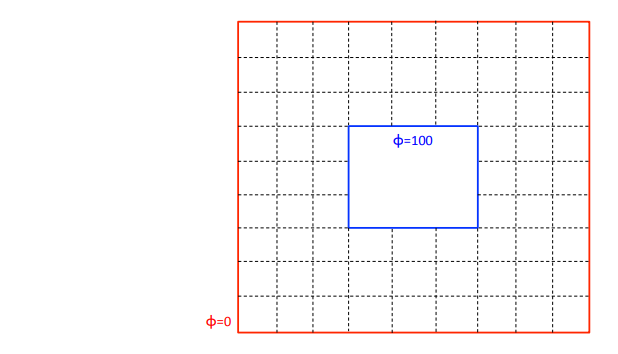

In [2]:
N = 51                # Número de puntos en cada lado de la malla (N x N)
L = 1.0               # Longitud del dominio de la malla (L x L)
d = L / (N - 1)       # Espaciado de la malla (d)
k = 3                 # Proporción entre los cuadrados
tolerance = 1e-6      # Tolerancia para criterio de convergencia
max_iteration = 10000 # Límite de iteraciones

phi = np.zeros((N,N)) 

In [3]:
# Definición de la frontera interior
phi_int = 100

i_min_int = N // k 
i_max_int =  (k-1)* N //k
j_min_int = N // k
j_max_int = (k-1) * N // k 

phi[j_min_int, i_min_int:i_max_int + 1] = phi_int
phi[j_max_int, i_min_int:i_max_int + 1] = phi_int

phi[j_min_int:j_max_int + 1, i_min_int] = phi_int
phi[j_min_int:j_max_int + 1, i_max_int] = phi_int

# Definición de la frontera exterior
phi_ext = 0

phi[0, :] = phi_ext
phi[N - 1, :] = phi_ext
phi[1:N - 1, 0] = phi_ext
phi[1:N - 1, N - 1] = phi_ext

In [4]:
for n in range(max_iteration):
    prev_phi = phi.copy()
    max_diff = 0.0
    # Iterar sobre los puntos (excluyendo las fronteras externas)
    for j in range(1, N - 1):
        for i in range(1, N - 1):
            if not (j >= j_min_int and j <= j_max_int and i >= i_min_int and i <= i_max_int and
                    (j == j_min_int or j == j_max_int or i == i_min_int or i == i_max_int)):  
                
                # Ecuación de Diferencias Finitas
                phi[j, i] = 0.25 * (phi[j + 1, i] + phi[j - 1, i] +
                                    phi[j, i + 1] + phi[j, i - 1])

                diff = abs(phi[j, i] - prev_phi[j, i])
                if diff > max_diff: max_diff = diff

    if max_diff < tolerance:
        print(f"Convergencia alcanzada en {n} iteraciones")
        break
        
    if n == max_iteration - 1:
        print(f"Máximo de {max_iteration} iteraciones alcanzado sin converger.")


Convergencia alcanzada en 903 iteraciones


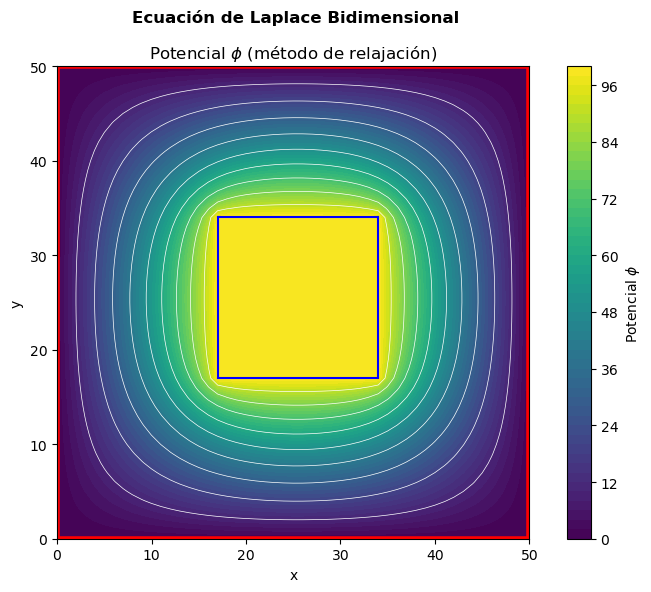

In [5]:
plt.figure(figsize=(8, 6))
# Mapa de calor
contour = plt.contourf(phi, cmap='viridis', levels=50) 
plt.colorbar(contour, label='Potencial $\phi$')

# Equipotenciales
plt.contour(phi, colors='white', linewidths=0.5, levels=[10, 20, 30, 40, 50, 60, 70, 80, 90])

# Fronteras internas
plt.plot([i_min_int, i_max_int], [j_min_int, j_min_int], 'b-', linewidth=1.5)
plt.plot([i_min_int, i_max_int], [j_max_int, j_max_int], 'b-', linewidth=1.5)
plt.plot([i_min_int, i_min_int], [j_min_int, j_max_int], 'b-', linewidth=1.5)
plt.plot([i_max_int, i_max_int], [j_min_int, j_max_int], 'b-', linewidth=1.5)

# Fronteras externas
plt.plot([0, N-1], [0, 0], 'r-', linewidth=4)
plt.plot([0, N-1], [N-1, N-1], 'r-', linewidth=4)
plt.plot([0, 0], [0, N-1], 'r-', linewidth=4)
plt.plot([N-1, N-1], [0, N-1], 'r-', linewidth=4)

plt.suptitle('Ecuación de Laplace Bidimensional', fontweight = 'bold')
plt.title('Potencial $\phi$ (método de relajación)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

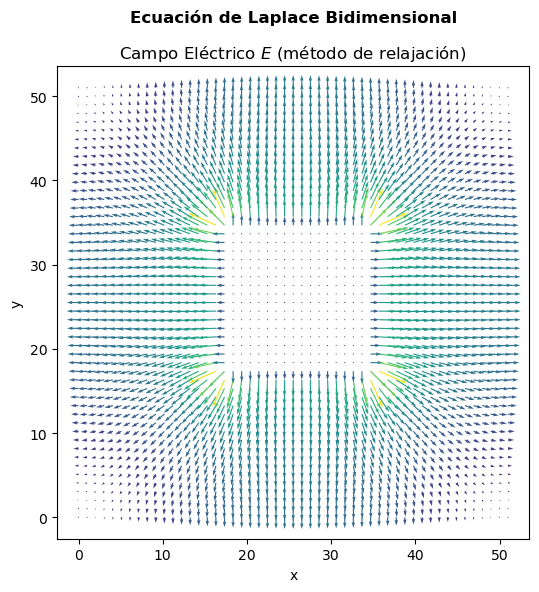

In [6]:
Ey, Ex = np.gradient(phi,L)
Ey, Ex = -Ey,-Ex
E = np.sqrt(Ex**2  + Ey**2)

x, y = np.meshgrid(np.linspace(0, N*L, N), np.linspace(0, N*L, N))

plt.figure(figsize=(8, 6))

# Campo vectorial
plt.quiver(x,y, Ex, Ey, E, scale=200, label='Campo Eléctrico $E$')

plt.suptitle('Ecuación de Laplace Bidimensional', fontweight = 'bold')
plt.title('Campo Eléctrico $E$ (método de relajación)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

### Sección 2.
Genera un programa para resolver el problema de un círculo en el interior y un cuadrado al exterior, como se muestra en la figura. El cuadrado exterior se encuentra aterrizado (potencial $\phi = 0$), mientras que el círculo interno tiene un potencial $\phi(\theta) = sin^2\theta.$

In [7]:
N = 51                # Número de puntos en cada lado de la malla (N x N)
L = 1.0               # Longitud del dominio de la malla (L x L)
d = L / (N - 1)       # Espaciado de la malla (d)
tolerance = 1e-6      # Tolerancia para criterio de convergencia
max_iteration = 10000 # Límite de iteraciones

R = N//6              # radio del círculo
x0, y0 = N//2, N//2   # centro del círculo 

phi = np.zeros((N,N)) 

In [8]:
fixed = np.zeros((N,N), dtype = bool) # fijar la frontera

# Definición de la frontera interior
def phi_int(t):
    return np.sin(t)**2
    
for i in range(1, N - 1):
    for j in range(1, N - 1):
        r = np.sqrt((i-x0)**2 + (j-y0)**2)
        if r <= R: # if np.abs(r-R) <= d/2:
            theta = np.arctan2(j-y0, i-x0)
            phi[j, i] = phi_int(theta)
            fixed[j,i] = True

# Definición de la frontera exterior
phi_ext = 0

phi[0, :], fixed[0, :] = phi_ext, True
phi[N-1, :], fixed[N-1, :] = phi_ext, True
phi[1: N-1, 0], fixed[1: N-1, 0] = phi_ext,True
phi[1: N-1, N-1], fixed[1: N-1, N-1] = phi_ext, True

In [9]:
for n in range(max_iteration):
    prev_phi = phi.copy()
    max_diff = 0.0
    # Iterar sobre los puntos (excluyendo las fronteras)
    for j in range(0, N - 1):
        for i in range(0, N - 1):
            if not fixed[j,i]:  
                # Ecuación de Diferencias Finitas
                phi[j, i] = 0.25 * (phi[j + 1, i] + phi[j - 1, i] +
                                    phi[j, i + 1] + phi[j, i - 1])

                diff = abs(phi[j, i] - prev_phi[j, i])
                if diff > max_diff: max_diff = diff

    if max_diff < tolerance:
        print(f"Convergencia alcanzada en {n} iteraciones")
        break
        
    if n == max_iteration - 1:
        print(f"Máximo de {max_iteration} iteraciones alcanzado sin converger.")

Convergencia alcanzada en 662 iteraciones


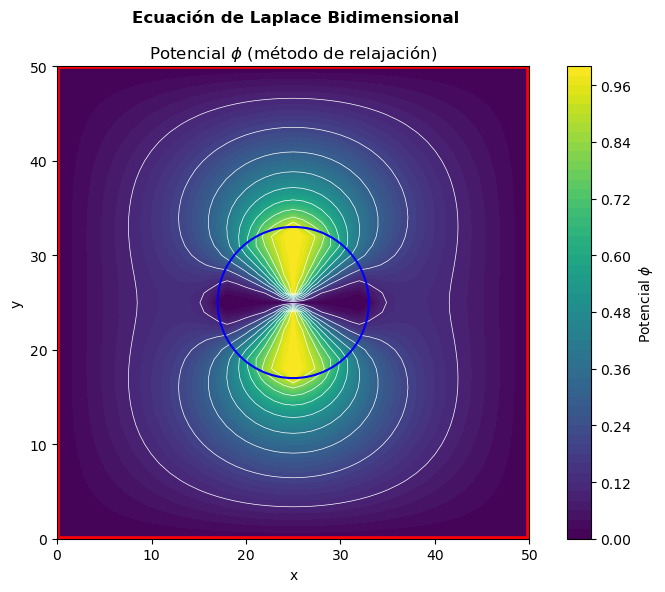

In [10]:
plt.figure(figsize=(8, 6))
# Mapa de calor
contour = plt.contourf(phi, cmap='viridis', levels=50) 
plt.colorbar(contour, label='Potencial $\phi$')

# Equipotenciales
plt.contour(phi, colors='white', linewidths=0.5, levels=[0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9])

# Fronteras internas
t = np.linspace(0, 2*np.pi,100)
plt.plot(R*np.cos(t) + x0, R*np.sin(t)+ y0, 'b-', linewidth=1.5)

# Fronteras externas
plt.plot([0, N-1], [0, 0], 'r-', linewidth=4)
plt.plot([0, N-1], [N-1, N-1], 'r-', linewidth=4)
plt.plot([0, 0], [0, N-1], 'r-', linewidth=4)
plt.plot([N-1, N-1], [0, N-1], 'r-', linewidth=4)

plt.suptitle('Ecuación de Laplace Bidimensional', fontweight = 'bold')
plt.title('Potencial $\phi$ (método de relajación)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

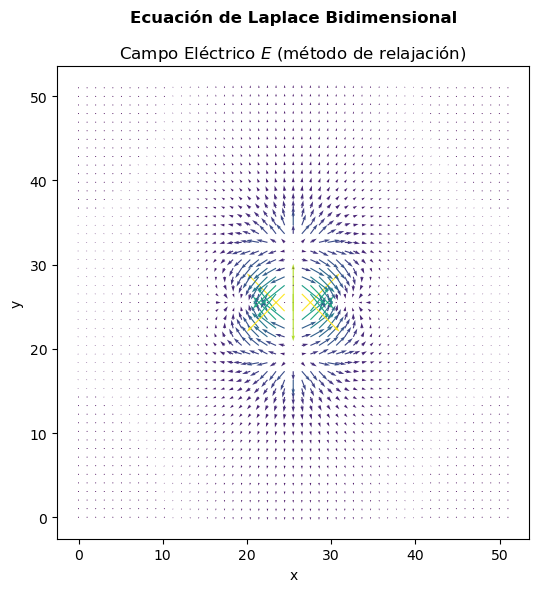

In [11]:
Ey, Ex = np.gradient(phi,L) # toma primerovalores sobre y
Ey, Ex = -Ey,-Ex
E = np.sqrt(Ex**2  + Ey**2)

x, y = np.meshgrid(np.linspace(0, N*L, N), np.linspace(0, N*L, N))

plt.figure(figsize=(8, 6))

# Campo vectorial
plt.quiver(x,y, Ex, Ey, E,scale = 5, label='Campo Eléctrico $E$')

plt.suptitle('Ecuación de Laplace Bidimensional', fontweight = 'bold')
plt.title('Campo Eléctrico $E$ (método de relajación)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()